# Analyzing the Research Questions

In [2]:
# Import packages and connect to Oracle database
import matplotlib.pyplot as plt
import pandas as pd

import oracledb
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_evama200", password="a36961662", dsn=dsn)

print("Connected!")

Connected!


## Research Question 1
### Are certain genres associated with significantly different IMDb user ratings and worldwide box office revenue?

The query below joins three tables:
- `movies`: contains IMDb ratings for movies
- `movie_genres`: links each movie to its genres (one row per genre, as a movie can belong to many genres)
- `box_office`: contains worldwide revenue

Movies are grouped by genre, and we compute the average IMDb rating, average worldwide revenue, and count of movies per genre. Results are ordered by average revenue descending.
- Two JOIN statements are used to connect the tables: 
  - 1. joining `movies` to `movie_genres` with `tconst` to obtain genres for each movie
  - 2. then, using this to join `box_office` with `norm_title` to get worldwide revenue
- WHERE clause filters out movies with missing revenue values
- GROUP BY is applied by genre
- `AVG` was applied to compute average IMDb rating and average worldwide revenue per genre
- `COUNT(DISTINCT tconst)` to count how many movies belong to each genre; using `DISTINCT` prevents counting the same movie twice, as a movie can have many genres
- Results are ordered by average revenue, with highest grossing genres appearing first

In [ ]:
# Read and execute SQL
cur = connection.cursor()

cur.execute(
    """
    SELECT mg.genre,
        COUNT(DISTINCT m.tconst) AS movie_count,
        AVG(m.imdb_rating) AS avg_imdb_rating,
        AVG(bo.worldwide_revenue) AS avg_revenue
    FROM movies m
        JOIN movie_genres mg ON m.tconst = mg.tconst
        JOIN box_office bo ON m.norm_title = bo.norm_title
    WHERE bo.worldwide_revenue IS NOT NULL
    GROUP BY mg.genre
    ORDER BY avg_revenue DESC
    """)

columns = [col[0] for col in cur.description] # extract the column names
rq1_df = pd.DataFrame(cur.fetchall(), columns = columns) # put together the dataframe 
cur.close() #close connection

          GENRE  MOVIE_COUNT  AVG_IMDB_RATING   AVG_REVENUE
0       Fantasy            2         5.750000  3.984000e+08
1     Animation            2         5.900000  3.930601e+08
2     Adventure            5         6.000000  3.388188e+08
3         Crime            1         6.000000  3.264791e+08
4        Action            4         6.450000  3.166564e+08
5      Thriller            4         6.975000  2.300078e+08
6        Sci-Fi            1         7.400000  1.765068e+08
7       Mystery            2         6.700000  1.677116e+08
8        Comedy            9         6.655556  1.503816e+08
9         Drama           15         7.126667  1.031939e+08
10    Biography            1         6.800000  6.655846e+07
11       Family            1         5.500000  3.351933e+07
12       Horror            2         5.850000  2.752926e+07
13      Romance            1         7.200000  2.664235e+07
14  Documentary            1         6.000000  2.359104e+07


/var/folders/ss/ql1sn935541fnltcl8b_8nph0000gn/T/ipykernel_53140/1504937740.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq1_df = pd.read_sql(


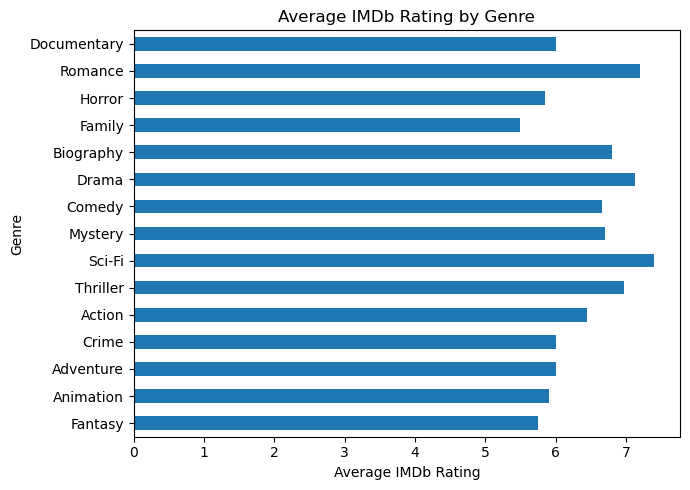

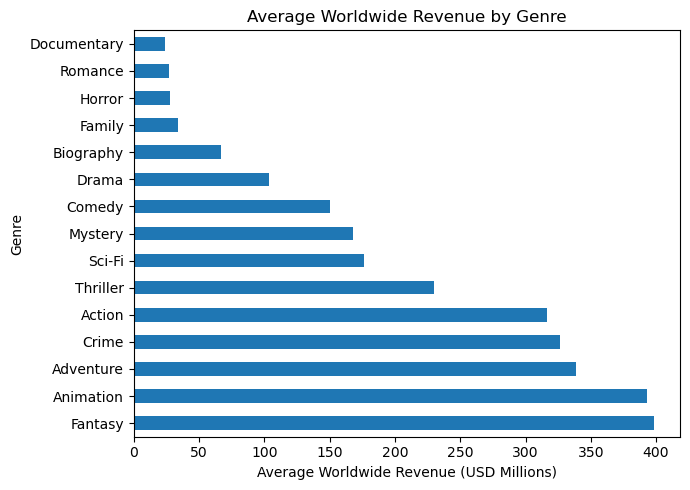

In [16]:
# Figure 1: Average IMDb Rating by Genre
rq1_df.plot(x = "GENRE", y = "AVG_IMDB_RATING", kind = "barh", figsize = (7, 5), legend = False)
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("Average IMDb Rating by Genre")
plt.tight_layout()
plt.show()

# Figure 2: Average Worldwide Revenue by Genre
rq1_plot2 = rq1_df.copy()
rq1_plot2["AVG_REVENUE"] = rq1_plot2["AVG_REVENUE"] / 1000000  # Revenue in millions

rq1_plot2.plot(x = "GENRE", y = "AVG_REVENUE", kind = "barh", figsize = (7, 5), legend=False)
plt.xlabel("Average Worldwide Revenue (USD Millions)")
plt.ylabel("Genre")
plt.title("Average Worldwide Revenue by Genre")
plt.tight_layout()
plt.show()

## Research Question 2
### For movies, is the runtime length associated with higher or lower average IMDb user ratings and box office revenue?

We categorize movies into 3 different runtime groups to compare their average IMDb ratings and box office revenue across groups. `movies` and `box_office` are joined by `norm_title` in order to obtain both runtime and IMDb rating information for each movie, and revenue into a single table. 
- Three separate views are created:
  - 1. `short_films` view contains movies with runtime under 90 minutes
  - 2. `medium_films` view contains movies with runtime under 120 minutes and greater than 90 minutes
  - 3. `long films` view contains movies with runtime greater than 120 minutes
- Each view filters for the respective runtime range, excluding movies that contain missing revenue values

Once the three views are created, they are combined into a single result using UNION ALL, merging the rows from all three views togther. 
- GROUP BY `runtime_bin` in order for each category to get its own row as an output
- Aggregate functions are applied: `AVG` to compute average IMDb rating and average revenue, `SUM` to find the total revenue, and `COUNT` to determine how many movies are in each bin

In [18]:
# Create views, execute code
cur = connection.cursor()

cur.execute(
    """
    CREATE VIEW short_films AS
        SELECT m.runtime_minutes, m.imdb_rating, bo.worldwide_revenue, 'Short' AS runtime_bin
        FROM movies m
        JOIN box_office bo ON m.norm_title = bo.norm_title
        WHERE m.runtime_minutes < 90
        AND bo.worldwide_revenue IS NOT NULL
    """)

cur.execute(
    """
    CREATE VIEW medium_films AS
        SELECT m.runtime_minutes, m.imdb_rating, bo.worldwide_revenue, 'Medium' AS runtime_bin
        FROM movies m
        JOIN box_office bo ON m.norm_title = bo.norm_title
        WHERE m.runtime_minutes BETWEEN 90 AND 120
        AND bo.worldwide_revenue IS NOT NULL
    """)

cur.execute(
    """
    CREATE VIEW long_films AS
        SELECT m.runtime_minutes, m.imdb_rating, bo.worldwide_revenue, 'Long' AS runtime_bin
        FROM movies m
        JOIN box_office bo ON m.norm_title = bo.norm_title
        WHERE m.runtime_minutes > 120
        AND bo.worldwide_revenue IS NOT NULL
    """)

# Obtain results
cur.execute(
    """
    SELECT runtime_bin, COUNT(*) AS movie_count, 
        AVG(imdb_rating) AS avg_imdb_rating,
        AVG(worldwide_revenue) AS avg_revenue, 
        SUM(worldwide_revenue) AS total_revenue
    FROM (SELECT * FROM short_films
        UNION SELECT * FROM medium_films
        UNION SELECT * FROM long_films)
    GROUP BY runtime_bin
    ORDER BY runtime_bin
    """)

columns = [col[0] for col in cur.description] # extract the column names
rq2_df = pd.DataFrame(cur.fetchall(), columns = columns) # put together the dataframe 
cur.close() #close connection

print(rq2_df)

DatabaseError: ORA-00955: name is already used by an existing object
Help: https://docs.oracle.com/error-help/db/ora-00955/

In [17]:
# Figure 1: Average IMDb Rating by Runtime
rq2_df.plot(x = "RUNTIME_BIN", y = "AVG_IMDB_RATING", kind = "bar", figsize=(7, 5), legend = False)
plt.xlabel("Runtime")
plt.ylabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Runtime")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Figure 2: Average Worldwide Revenue by Runtime
rq2_plot2 = rq2_df.copy()
rq2_plot2["AVG_REVENUE"] = rq2_plot2["AVG_REVENUE"] / 1000000 # Revenue in terms of millions

rq2_plot2.plot(x = "RUNTIME_BIN", y = "AVG_REVENUE", kind = "bar", figsize = (7, 5), legend = False)
plt.xlabel("Runtime")
plt.ylabel("Average Worldwide Revenue (USD Millions)")
plt.title("Average Worldwide Revenue by Runtime")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'rq2_df' is not defined

In [7]:
# Create views for high and low rated movies
cur = connection.cursor()

cur.execute(
    """
    CREATE VIEW high_rated AS
        SELECT norm_title, tomatometer_rating, critics_consensus, 'High' AS rating_group
        FROM rt_reviews
        WHERE tomatometer_rating >= 60
        AND critics_consensus IS NOT NULL
    """)

cur.execute(
    """
    CREATE VIEW low_rated AS
        SELECT norm_title, tomatometer_rating, critics_consensus, 'Low' AS rating_group
        FROM rt_reviews
        WHERE tomatometer_rating < 60
        AND critics_consensus IS NOT NULL
    """)

# Obtain results
cur.execute(
    """
    SELECT rating_group, critics_consensus
    FROM (SELECT * FROM high_rated
          UNION SELECT * FROM low_rated)
    ORDER BY rating_group
    """)

columns = [col[0] for col in cur.description]  # extract column names
rq3_df = pd.DataFrame(cur.fetchall(), columns=columns)  # put together the dataframe
cur.close()  # close cursor

print(rq3_df.head())
print(rq3_df["RATING_GROUP"].value_counts())

  RATING_GROUP                                  CRITICS_CONSENSUS
0         High  Beautifully filmed and powerfully acted, 1,000...
1         High  Sidney Lumet's feature debut is a superbly wri...
2         High  With a witty script full of satirical overtone...
3         High  2 Days in New York breezes past its shortcomin...
4         High  Delpy proves not only to be an adept actress, ...
RATING_GROUP
High    1204
Low      796
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Fit CountVectorizer for high and low tomatometer rating groups 
high_texts = rq3_df[rq3_df["RATING_GROUP"] == "High"]["CRITICS_CONSENSUS"].tolist()
low_texts  = rq3_df[rq3_df["RATING_GROUP"] == "Low"]["CRITICS_CONSENSUS"].tolist()

def get_top_words(texts, n=15):
    vec = CountVectorizer(
        stop_words = "english", # built-in english stopwords
        min_df = 2, # ignore words appearing in fewer than 2 reviews
        ngram_range=(1, 1)) # single words only
    
    X = vec.fit_transform(texts) # document-term matrix
    word_counts = X.sum(axis=0).toarray().flatten() # convert to 1D array
     
    vocab = vec.get_feature_names_out()
    top_idx = word_counts.argsort()[-n:] # indices of top n words

    return pd.DataFrame({"word":  vocab[top_idx], "count": word_counts[top_idx]})

high_df = get_top_words(high_texts)
low_df  = get_top_words(low_texts)

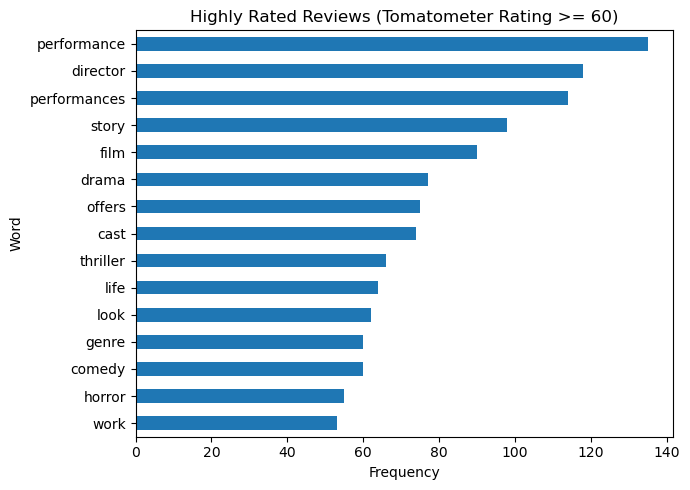

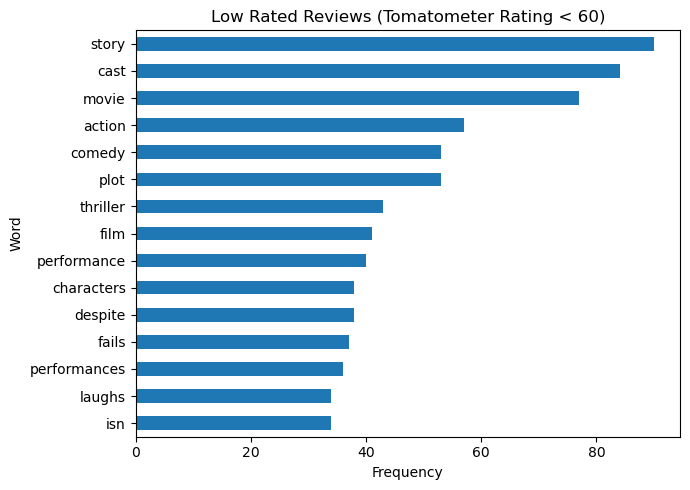

In [21]:
# High-rated plot 
high_df.plot(x = "word", y = "count", kind = "barh", figsize = (7, 5), legend = False)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Highly Rated Reviews (Tomatometer Rating >= 60)")
plt.tight_layout()
plt.show()

# Low-rated plot
low_df.plot(x = "word", y = "count", kind = "barh", figsize=(7, 5), legend = False)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Low Rated Reviews (Tomatometer Rating < 60)")
plt.tight_layout()
plt.show()